# Results Validation
### Go over results and see if they are problomatic
CARVA had some problomatic results, here we will test them.

for starters, we will examine how weird the randomized results truly are

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from scipy.stats import norm
import scipy.stats as stats

In [4]:
datadir = Path.cwd().parent / "out/pcnet2-entrez/random_bulk_like_binary"
datadir2 = Path.cwd().parent / "out/pcnet2-entrez/random_bulk_quant1"
print(datadir)

/home/elkon2/shacharbavly/networks/CARVA/out/pcnet2-entrez/random_bulk_like_binary


In [6]:
csv_path = datadir / "random_bulk_like_binary_results_summary.tsv" #"random_2_results_summary.tsv"

# read csv
df = pd.read_csv(csv_path, sep="\t")
display(df.head())
# extract p-values
print("sorted by pval:")
display(df.sort_values(by="p_size", ascending=True).head(10))
pvals = df["p_size"].to_numpy()

# keep valid p-values only
pvals = pvals[(pvals > 0) & (pvals <= 1)]

n = len(pvals)

# expected vs observed quantiles
observed = np.sort(pvals)
expected = (np.arange(1, n + 1)) / (n + 1)


,trait_rare,trait_common,network,transform,normalization,mean_nps,null_mean_nps,p_mean_nps,size,null_size,p_size,coloc_type
0,1_random_bulk_like_lupus,1_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.007421,0.012762,7.878000e-01,230,245.948667,0.24490,binary
1,7_random_bulk_like_lupus,7_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.019776,-0.022964,4.472000e-02,246,222.423333,0.08067,binary
2,9_random_bulk_like_lupus,9_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.114904,0.006125,2.411000e-08,251,227.660000,0.08683,binary
3,10_random_bulk_like_lupus,10_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,-0.049339,-0.028537,3.076000e-01,211,215.494333,0.73780,binary
4,5_random_bulk_like_lupus,5_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.069251,0.021669,5.638000e-03,262,222.232667,0.00316,binary


sorted by pval:


,trait_rare,trait_common,network,transform,normalization,mean_nps,null_mean_nps,p_mean_nps,size,null_size,p_size,coloc_type
19,17_random_bulk_like_lupus,17_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.151680,-0.011200,2.449000e-14,317,239.999333,2.838000e-08,binary
14,3_random_bulk_like_lupus,3_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,-0.159987,-0.034143,5.033000e-10,154,226.126000,1.198000e-07,binary
197,198_random_bulk_like_lupus,198_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.139949,0.013820,5.436000e-09,322,250.367000,3.116000e-07,binary
147,150_random_bulk_like_lupus,150_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.111354,0.019220,6.194000e-06,328,264.906667,1.453000e-05,binary
142,143_random_bulk_like_lupus,143_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.093198,0.000546,1.735000e-06,288,231.086333,2.580000e-05,binary
54,60_random_bulk_like_lupus,60_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.120511,-0.010224,3.911000e-11,300,244.256333,7.619000e-05,binary
10,6_random_bulk_like_lupus,6_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,-0.066601,-0.045606,3.118000e-01,297,244.787000,1.458000e-04,binary
60,61_random_bulk_like_lupus,61_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,-0.031734,0.013646,2.113000e-02,161,210.616333,1.788000e-04,binary
84,84_random_bulk_like_lupus,84_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.036050,0.002121,9.146000e-02,307,255.850667,2.895000e-04,binary
5,2_random_bulk_like_lupus,2_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.100193,0.012147,3.573000e-06,294,244.906667,4.221000e-04,binary


In [7]:
print(observed)

[2.838e-08 1.198e-07 3.116e-07 1.453e-05 2.580e-05 7.619e-05 1.458e-04
 1.788e-04 2.895e-04 4.221e-04 8.044e-04 1.183e-03 1.376e-03 1.609e-03
 1.645e-03 1.867e-03 2.472e-03 2.592e-03 2.884e-03 3.160e-03 4.126e-03
 4.200e-03 4.769e-03 5.278e-03 6.826e-03 7.658e-03 8.189e-03 1.160e-02
 1.223e-02 1.449e-02 1.642e-02 1.796e-02 1.825e-02 1.915e-02 1.949e-02
 2.146e-02 2.414e-02 2.542e-02 2.770e-02 2.773e-02 2.786e-02 2.894e-02
 2.962e-02 3.071e-02 3.187e-02 3.486e-02 3.654e-02 3.845e-02 4.126e-02
 4.461e-02 4.599e-02 4.616e-02 4.860e-02 4.886e-02 5.041e-02 5.211e-02
 5.259e-02 5.348e-02 5.778e-02 6.414e-02 6.497e-02 6.619e-02 6.848e-02
 6.995e-02 7.576e-02 7.754e-02 7.796e-02 7.834e-02 7.864e-02 8.067e-02
 8.182e-02 8.683e-02 9.048e-02 9.131e-02 9.531e-02 9.576e-02 1.039e-01
 1.062e-01 1.117e-01 1.169e-01 1.174e-01 1.194e-01 1.199e-01 1.308e-01
 1.339e-01 1.462e-01 1.584e-01 1.708e-01 1.737e-01 1.776e-01 1.800e-01
 2.094e-01 2.127e-01 2.247e-01 2.277e-01 2.428e-01 2.449e-01 2.487e-01
 2.492

In [8]:
# transfers the two sided p value back into z scores
def add_signed_zscore(df):
    # avoid p = 0
    p = df["p_size"].clip(lower=1e-300)

    # two-sided p-value to z magnitude
    z = norm.ppf(1 - p / 2)

    z = np.clip(z, a_min=None, a_max=37.0)
    # sign: size < null_size -> negative
    sign = np.where(df["size"] < df["null_size"], -1.0, 1.0)

    df = df.copy()
    df["z_score"] = z * sign
    return df


In [6]:
def add_signed_zscore_one_side(df):
    # avoid p = 0
    p = df["p_size"].clip(lower=1e-300)

    # two-sided p-value to z magnitude
    z = norm.ppf(1 - p)

    # sign: size < null_size -> negative
    sign = np.where(df["size"] < df["null_size"], -1.0, 1.0)

    df = df.copy()
    df["z_score"] = z * sign
    return df


In [9]:
df = add_signed_zscore(df)

In [10]:
display(df.head()) # check z scores added correctly

,trait_rare,trait_common,network,transform,normalization,mean_nps,null_mean_nps,p_mean_nps,size,null_size,p_size,coloc_type,z_score
0,1_random_bulk_like_lupus,1_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.007421,0.012762,7.878000e-01,230,245.948667,0.24490,binary,-1.162826
1,7_random_bulk_like_lupus,7_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.019776,-0.022964,4.472000e-02,246,222.423333,0.08067,binary,1.746812
2,9_random_bulk_like_lupus,9_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.114904,0.006125,2.411000e-08,251,227.660000,0.08683,binary,1.712362
3,10_random_bulk_like_lupus,10_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,-0.049339,-0.028537,3.076000e-01,211,215.494333,0.73780,binary,-0.334768
4,5_random_bulk_like_lupus,5_random_bulk_like_lupus,pcnet2-entrez,neglog10,sum,0.069251,0.021669,5.638000e-03,262,222.232667,0.00316,binary,2.951729


In [11]:
zs = df["z_score"].to_numpy()

# keep valid p-values only

n = len(zs)

# expected vs observed quantiles
observed_z = np.sort(zs)
expected = (np.arange(1, n + 1)) / (n + 1)

In [12]:
print(zs)

[-1.16282626  1.74681174  1.71236188 -0.33476813  2.95172913  3.5258663
 -0.23179145  3.02674794 -0.99199493  0.49485851  3.79811615  0.66726951
 -0.55674744  2.97983891 -5.29380069 -3.15427027 -0.76444853 -1.61551137
  0.12932562  5.55114781 -2.18430287  0.29721811  0.97774593  3.24294752
 -2.78955826 -1.84546449 -1.08234333 -2.3994438  -2.36644176 -2.29979212
  2.09086687 -0.39763399  0.92955797 -1.96981131  2.23495962 -0.05467172
  1.94222391  1.69287113 -2.82223646  0.49811924 -0.66179907  0.36407768
 -0.16785163  0.88417825 -3.11061212  0.56967227  1.15229469  3.3512763
 -0.1351415   2.04090772  0.7273689  -1.36041068 -2.10998091  0.48243072
  3.95607892 -0.59476585  0.19230922  0.12970478 -1.45308556  2.19925212
 -3.74722737 -2.07002504 -1.11441778 -0.14070879  2.70521594 -2.2010851
  2.86836441 -0.20458036 -1.55519347  0.42559909  1.13780959  2.25489373
 -1.66576615 -0.5189437  -1.99548508 -2.16081025  0.36514925  1.68852758
 -0.48722343 -0.16658068 -1.66802885  2.33602382  1.76

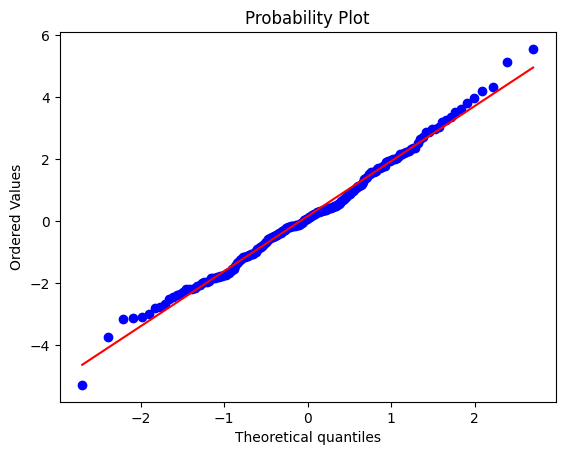

In [13]:
qq_fit = stats.probplot(observed_z, dist="norm", plot=plt, fit=True)
#plt.plot((-4, 4), (-4,4))

the above plot shows if the z scores are normally distributed, as they should be if the null distribution is ok.

In [ ]:
print(observed)

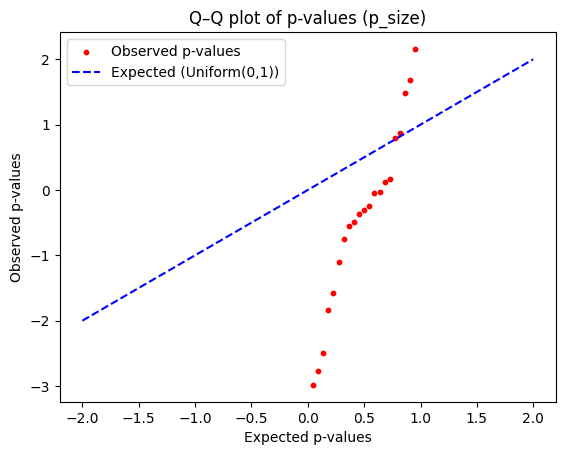

In [13]:
plt.figure()
plt.scatter(expected, observed, s=10, color="red", label="Observed p-values")
plt.plot([-2, 2], [-2, 2], color="blue", linestyle="--", label="Expected (Uniform(0,1))")
plt.xlabel("Expected p-values")
plt.ylabel("Observed p-values")
plt.title("Q–Q plot of p-values (p_size)")
plt.legend(loc="upper left")
plt.show()

In [ ]:
log_observed = -np.log10(np.sort(zs))
log_expected = -np.log10((np.arange(1, n + 1)) / (n + 1))

plt.figure()
plt.scatter(log_expected, log_observed, s=10, color="red", label="Observed p-values")
plt.plot(
    [0, max(log_expected)],
    [0, max(log_expected)],
    color="blue",
    linestyle="--",
    label="Expected (Uniform(0,1))"
)
plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("Q–Q plot of p-values (log scale)")
plt.legend(loc="upper left")
plt.show()


In [ ]:
def qq_plot_pvalues(df, p_col="p_size"):
    # drop missing and invalid p-values
    pvals = df[p_col].dropna()
    pvals = pvals[(pvals > 0) & (pvals <= 1)]

    n = len(pvals)
    if n == 0:
        raise ValueError("No valid p-values to plot")

    # sort observed p-values
    observed = np.sort(pvals.values)
    print(observed)
    # expected p-values from Uniform(0,1)
    expected = np.arange(1, n + 1) / (n + 1)

    plt.figure()
    plt.scatter(expected, observed)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("Expected p-values (Uniform(0,1))")
    plt.ylabel("Observed p-values")
    plt.title("QQ plot of p-values")
    plt.show()


In [ ]:
csv_path = datadir2 / "random_2_results_summary.tsv"

# read csv
df_full_random = pd.read_csv(csv_path, sep="\t")
display(df_full_random.sort_values(by="p_size", ascending=True).head(10))
qq_plot_pvalues(df_full_random)

In [ ]:
def log_qq_plot_pvalues(df, p_col="p_size"):
    # clean p-values
    pvals = df[p_col].dropna()
    pvals = pvals[(pvals > 0) & (pvals <= 1)]

    n = len(pvals)
    if n == 0:
        raise ValueError("No valid p-values to plot")

    # observed
    observed = -np.log10(np.sort(pvals.values))

    # expected under Uniform(0,1)
    expected = -np.log10(np.arange(1, n + 1) / (n + 1))

    plt.figure()
    plt.scatter(expected, observed)
    max_val = max(expected.max(), observed.max())
    plt.plot([0, max_val], [0, observed.max()])
    plt.xlabel("Expected log10(p)")
    plt.ylabel("Observed log10(p)")
    plt.title("-log10 QQ plot of p-values")
    plt.show()

In [ ]:
log_qq_plot_pvalues(df_full_random)